# 03｜NumPy 與 Pandas：定義決定結果

**115-1 地理資訊系統運用程式｜W3（10/01）**

上週用 5 行 `for` 迴圈做的分組統計，這週用 Pandas 一行就能做完。但本週真正的重點是：

> **同一份資料，換一個定義，結論就會改變。** agent 幾秒內就能算出「各區空站比例」，但「空站」怎麼定義、分母要算哪些站，要由你決定，而且要說得出理由。

| Part | 內容 |
|---|---|
| A | NumPy：陣列運算、向量化；比例就是布林值的平均 |
| B | Pandas 讀資料：先檢查型態（`read_json` 的陷阱） |
| C | 分組彙整：`groupby`，並用 W2 的迴圈驗證 |
| D | 多時段快照：`concat`、`pd.to_datetime`、`pivot_table`、`melt`、`merge` |
| E | 定義決定結果：空站的定義、分母、平均數與中位數 |
| F | matplotlib 中文圖表 |

**課前準備：** 從新雲端學院下載 `youbike_w3` 資料夾（老師在 3 個時段抓的快照），把整個資料夾上傳到雲端硬碟的 `115-1_GISprog/data/raw/`。

標示 **【練習】** 的儲存格請自己動手完成。

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 0. 路徑與中文字型

沿用 `00_Colab環境設定範本.ipynb` 的兩個儲存格。本週多了一個 `SNAP_DIR`，指向課堂用的快照資料夾。

In [4]:
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    PROJECT_DIR = Path("/content/drive/MyDrive/115-1_GISprog")
else:
    # 備援：本機執行時，notebook 位於 115-1_GISprog/notebooks/，上一層就是專案資料夾
    PROJECT_DIR = Path.cwd().parent

RAW_DIR = PROJECT_DIR / "data" / "raw"
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
OUTPUT_DIR = PROJECT_DIR / "outputs"
FONT_DIR = PROJECT_DIR / "fonts"

# 課堂用老師的快照；做 HW3 時改成你自己存快照的資料夾（HW2 存在 PROCESSED_DIR）
SNAP_DIR = RAW_DIR / "youbike_w3"

if not SNAP_DIR.exists():
    raise FileNotFoundError(f"找不到 {SNAP_DIR}，請把 youbike_w3 資料夾上傳到 115-1_GISprog/data/raw/")

快照檔 = sorted(SNAP_DIR.glob("youbike_*.json"))
print("執行環境：", "Google Colab" if IN_COLAB else "本機")
print("快照：", [p.name for p in 快照檔])

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
執行環境： Google Colab
快照： ['youbike_20260925_1230.json', 'youbike_20260925_1800.json', 'youbike_20260925_2330.json']


In [5]:
import urllib.request

import matplotlib.pyplot as plt
from matplotlib import font_manager

FONT_URL = "https://drive.google.com/uc?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_&export=download"
FONT_PATH = FONT_DIR / "TaipeiSansTCBeta-Regular.ttf"

if not FONT_PATH.exists():
    FONT_DIR.mkdir(parents=True, exist_ok=True)
    urllib.request.urlretrieve(FONT_URL, FONT_PATH)

font_manager.fontManager.addfont(str(FONT_PATH))     # 告訴 Matplotlib：「這個字型檔可以使用」
plt.rcParams["font.family"] = "Taipei Sans TC Beta"  # 指定之後畫圖預設使用這個中文字型
plt.rcParams["axes.unicode_minus"] = False           # 避免負號 − 顯示異常
print("已設定中文字型：", FONT_PATH.name)

已設定中文字型： TaipeiSansTCBeta-Regular.ttf


---

# Part A｜NumPy：陣列運算

## A1. 從 list 到陣列：向量化

W2 的資料是 list of dict。要算「每一站的可借車比例」，用 `for` 迴圈要一站一站算；NumPy 的**陣列（array）**可以整欄一起算，這叫做**向量化**。

In [6]:
import json

import numpy as np

with open(快照檔[0], encoding="utf-8") as f:
    data = json.load(f)       # json.load(f) 把 JSON 內容讀成 Python 物件：一個 list of dictionaries

可借 = np.array([r["available_rent_bikes"] for r in data])
# 對 data 裡的每一筆紀錄 r，取出它的 "available_rent_bikes"，變成 NumPy 陣列。

總柱 = np.array([r["Quantity"] for r in data])
# 對 data 裡的每一筆紀錄 r，取出它的 "Quantity"，變成 NumPy 陣列。

print("型態：", type(可借).__name__, "｜元素型態：", 可借.dtype, "｜形狀：", 可借.shape)
print("前 5 站的可借車：", 可借[:5])    # 代表切片出 索引 0、1、2、3、4 的元素

型態： ndarray ｜元素型態： int64 ｜形狀： (1807,)
前 5 站的可借車： [26 21  1 11  8]


(1807,) 後面的逗號不是打錯，而是 Python 表示「只有一個元素的 tuple」的方式，表示 可借 是一個一維的陣列。

In [7]:
# W2 的寫法：for 迴圈一站一站算
比例_迴圈 = []
for i in range(len(可借)):
    比例_迴圈.append(可借[i] / 總柱[i])

# NumPy 的寫法：整欄一起算
比例_向量 = 可借 / 總柱

print("前 5 站（迴圈）：", np.round(比例_迴圈[:5], 3))    # round()不是"四捨五入"，是"四捨六入五成雙"，又稱銀行家捨入。
print("前 5 站（向量）：", np.round(比例_向量[:5], 3))
assert np.allclose(比例_迴圈, 比例_向量), "兩種寫法的結果應該相同"

前 5 站（迴圈）： [0.929 1.    0.036 1.    0.5  ]
前 5 站（向量）： [0.929 1.    0.036 1.    0.5  ]


> assert np.allclose(比例_迴圈, 比例_向量), "兩種寫法的結果應該相同"

這行是在做「自動檢查兩種計算方式的結果是否一致」。

> np.allclose(比例_迴圈, 比例_向量)



在檢查 比例_迴圈 和 比例_向量 中的每個數值，是否都「足夠接近」。

為何不用

> 比例_迴圈 == 比例_向量

是因為浮點數運算常會有極小的誤差。

In [8]:
# 比較速度：%timeit 會重複執行很多次，取平均時間
%timeit [可借[i] / 總柱[i] for i in range(len(可借))]
%timeit 可借 / 總柱

734 µs ± 257 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)
8.07 µs ± 1.91 µs per loop (mean ± std. dev. of 7 runs, 100000 loops each)


**為什麼不用 `for` 迴圈？**

1. **好讀：** `可借 / 總柱` 一眼就看得出在算什麼，比較容易檢查 agent 寫得對不對。
2. **快：** 上面兩種寫法差了幾十倍。現在只有 1,800 站感覺不出來，資料到幾百萬筆時差別就很明顯。

## A2. 布林陣列：比例就是布林值的平均

比較運算會產生一個全是 `True`／`False` 的陣列。計算時 `True` 當成 1、`False` 當成 0，所以：

- `.sum()` → 有幾個 `True`，也就是**幾站**
- `.mean()` → `True` 佔多少，也就是**比例**

等一下的「空站比例」就是這樣算的。

In [9]:
是空站 = 可借 == 0

print("前 10 站：", 是空站[:10])
print("空站數：", 是空站.sum())
print("空站比例：", round(是空站.mean(), 3))
print("驗算：", 是空站.sum(), "/", len(是空站), "=", round(是空站.sum() / len(是空站), 3))

前 10 站： [False False False False False False False False False False]
空站數： 115
空站比例： 0.064
驗算： 115 / 1807 = 0.064


## A3. 平均數與中位數

In [10]:
print("每站可借車　平均數：", round(np.mean(可借), 1))
print("每站可借車　中位數：", np.median(可借))
print("最多的一站：", 可借.max(), "台")

每站可借車　平均數： 9.8
每站可借車　中位數： 8.0
最多的一站： 74 台


平均數比中位數大，代表有少數站的車特別多，把平均數拉高了。想知道「一般的站大概有幾台車」，中位數比較貼近。Part E 會看到這個選擇怎麼改變各區的排名。

**【練習 A】** 算出「滿站」（可還空位 = 0，也就是還不了車）的站數與比例。

提示：先仿照 `可借` 建立一個 `可還` 陣列，欄位是 `available_return_bikes`。

In [ ]:
# TODO：建立 可還 陣列，算出滿站數與滿站比例

---

# Part B｜Pandas：讀進來先檢查型態

NumPy 陣列只有數值，沒有欄位名稱。Pandas 的 **DataFrame** 是有欄位名稱的表格，每一欄是一個 **Series**，底層就是 NumPy 陣列。可以把 DataFrame 想成 GIS 圖層的屬性表。

## B1. 同一個檔案，兩種讀法

agent 讀 JSON 檔時很常直接寫 `pd.read_json()`。它讀進來的型態和 W2 的 `json.load()` **不一樣**。

In [11]:
import pandas as pd

df = pd.DataFrame(data)             # W2 的 json.load() 讀進來的 list of dict，再轉成 DataFrame
df_rj = pd.read_json(快照檔[0])      # agent 常寫的一行

pd.DataFrame({
    "json.load → DataFrame": df.dtypes.astype(str),
    "pd.read_json": df_rj.dtypes.astype(str),
})

,json.load → DataFrame,pd.read_json
sno,object,int64
sna,object,object
sarea,object,object
mday,object,object
ar,object,object
sareaen,object,object
snaen,object,object
aren,object,object
act,object,int64
srcUpdateTime,object,object


看 `sno` 和 `act` 這兩列：`read_json` 把「看起來像數字的字串」**自動轉成了整數**。

（`object` 和 `str` 都代表字串，只是不同版本的 pandas 顯示方式不同。）

In [12]:
print('json.load 版本，act == "1"：', (df["act"] == "1").sum(), "站")
print('read_json 版本，act == "1"：', (df_rj["act"] == "1").sum(), "站   ← 沒有報錯，只是一站都沒選到")

json.load 版本，act == "1"： 1780 站
read_json 版本，act == "1"： 0 站   ← 沒有報錯，只是一站都沒選到


**這種錯最危險：不會報錯，只是結果變成 0。** agent 如果用 `read_json` 讀檔，再用 W2 學到的 `act == "1"` 篩選，營運中的站數就會是 0。

- **解法一：** `pd.read_json(路徑, dtype=False)`，不自動轉換型態。
- **解法二：** 像本 notebook 一樣，先 `json.load()` 再轉成 DataFrame。

**不管用哪一種，讀進來的第一件事都是看 `df.dtypes`。**

## B2. 看一眼表格：`loc` 與 `iloc`

In [13]:
print("形狀（列數, 欄數）：", df.shape)
df.head(3)

形狀（列數, 欄數）： (1807, 18)


,sno,sna,sarea,mday,ar,sareaen,snaen,aren,act,srcUpdateTime,updateTime,infoTime,infoDate,Quantity,available_rent_bikes,latitude,longitude,available_return_bikes
0,500101001,YouBike2.0_捷運科技大樓站,大安區,2026-09-25 12:28:03,復興南路二段235號前,Daan Dist.,YouBike2.0_MRT Technology Bldg. Sta.,No.235， Sec. 2， Fuxing S. Rd.,1,2026-09-25 12:28:52,2026-09-25 12:28:52,2026-09-25 12:28:03,2026-09-25,28,26,25.02605,121.54360,2
1,500101002,YouBike2.0_復興南路二段273號前,大安區,2026-09-25 12:28:03,復興南路二段273號西側,Daan Dist.,YouBike2.0_No.273， Sec. 2， Fuxing S. Rd.,No.273， Sec. 2， Fuxing S. Rd. (West),1,2026-09-25 12:28:52,2026-09-25 12:28:52,2026-09-25 12:28:03,2026-09-25,21,21,25.02565,121.54357,0
2,500101003,YouBike2.0_國北教大實小東側門,大安區,2026-09-25 12:28:03,和平東路二段96巷7號,Daan Dist.,YouBike2.0_NTUE Experiment Elementary School (...,No. 7， Ln. 96， Sec. 2， Heping E. Rd,1,2026-09-25 12:28:52,2026-09-25 12:28:52,2026-09-25 12:28:03,2026-09-25,28,1,25.02429,121.54124,27


In [14]:
# iloc 用「索引」：第 0–2 列、第 0–3 欄（和 list 一樣，不包含結尾）
df.iloc[0:3, 0:4]

,sno,sna,sarea,mday
0,500101001,YouBike2.0_捷運科技大樓站,大安區,2026-09-25 12:28:03
1,500101002,YouBike2.0_復興南路二段273號前,大安區,2026-09-25 12:28:03
2,500101003,YouBike2.0_國北教大實小東側門,大安區,2026-09-25 12:28:03


In [15]:
# loc 用「標籤」：列標籤 0 到 2、指定欄名（注意：loc 的 0:2 包含 2）
df.loc[0:2, ["sna", "sarea", "act", "available_rent_bikes"]]

,sna,sarea,act,available_rent_bikes
0,YouBike2.0_捷運科技大樓站,大安區,1,26
1,YouBike2.0_復興南路二段273號前,大安區,1,21
2,YouBike2.0_國北教大實小東側門,大安區,1,1


## B3. 布林篩選，以及真假值陷阱的 Pandas 版

In [16]:
營運中的站 = df[df["act"] == "1"]
print("全部：", len(df), "站｜營運中：", len(營運中的站), "站")

# W2 的陷阱換個樣子又出現了：字串 "0" 轉成 bool 也是 True
print('df["act"].astype(bool) 的 True：', df["act"].astype(bool).sum(), "站   ← 停用站也被當成營運中")

全部： 1807 站｜營運中： 1780 站
df["act"].astype(bool) 的 True： 1807 站   ← 停用站也被當成營運中


多個條件要用 `&`（而且）、`|`（或者），**每個條件都要加括號**：

```python
df[(df["act"] == "0") & (df["available_rent_bikes"] > 0)]
```

**【練習 B】** 找出「暫停營運，但可借車不是 0」的站，印出站名、行政區、可借車數，並算出這些站合計有幾台車。

這些車要不要算進「可借車總數」？把你的決定寫進筆記。

In [ ]:
# TODO：用兩個條件篩選，印出 sna、sarea、available_rent_bikes，再加總可借車

---

# Part C｜分組彙整：`groupby`

## C1. W2 的 5 行迴圈 → 1 行 `groupby`

In [17]:
df["營運中"] = df["act"] == "1"      # 明確比較，得到 True／False

各區 = df.groupby("sarea").agg(
    站數=("sno", "size"),
    營運中站數=("營運中", "sum"),
    可借車總數=("available_rent_bikes", "sum"),
)
各區.sort_values("站數", ascending=False)

,站數,營運中站數,可借車總數
sarea,,,
內湖區,228,226,1678
大安區,217,213,2129
中山區,205,199,1906
士林區,156,152,1640
中正區,138,138,1457
北投區,133,131,1687
信義區,129,129,1518
文山區,124,122,1179
南港區,122,122,1293


讀法：「依 `sarea` 分組，每一組算三個數字：`sno` 有幾筆、`營運中` 有幾個 `True`、`available_rent_bikes` 的總和。」

## C2. 用 W2 的迴圈驗證 agent 的一行程式

一行程式很方便，但**你怎麼知道它算對了？** 用上週已經看懂的迴圈再算一次，用 `assert` 比對。

In [18]:
站數_迴圈 = {}
for r in data:
    站數_迴圈[r["sarea"]] = 站數_迴圈.get(r["sarea"], 0) + 1

for 區, n in 站數_迴圈.items():
    assert 各區.loc[區, "站數"] == n, f"{區} 不一致：groupby 是 {各區.loc[區, '站數']}，迴圈是 {n}"

print("groupby 與迴圈的站數一致，共", len(站數_迴圈), "類")

groupby 與迴圈的站數一致，共 13 類


## C3. `sum`、`mean`、`median` 在這裡各代表什麼？

In [19]:
df.groupby("sarea")["available_rent_bikes"].agg(["sum", "mean", "median"]).round(1).sort_values("sum", ascending=False)

,sum,mean,median
sarea,,,
大安區,2129,9.8,7.0
中山區,1906,9.3,7.0
北投區,1687,12.7,11.0
內湖區,1678,7.4,6.0
士林區,1640,10.5,9.0
信義區,1518,11.8,6.0
中正區,1457,10.6,9.0
南港區,1293,10.6,8.0
文山區,1179,9.5,8.0


**【練習 C】**（寫在筆記裡，不用寫程式）

- `sum` 最大的區和 `mean` 最大的區是同一區嗎？
- 想回答「在這一區比較容易借到車嗎？」，應該看 `sum` 還是 `mean`（或 `median`）？為什麼？

提示：`sum` 會受到「這一區有幾站」影響。

---

# Part D｜多時段快照

## D1. 把多份快照接成一個長表格：`concat`

In [20]:
def 讀快照(path):
    """讀一份 YouBike 快照 JSON，回傳 DataFrame，並加上來源檔名欄位。"""
    with open(path, encoding="utf-8") as f:
        d = pd.DataFrame(json.load(f))
    d["檔名"] = path.name
    return d


長表 = pd.concat([讀快照(p) for p in 快照檔], ignore_index=True)

print("長表形狀：", 長表.shape)
長表.groupby("檔名").size()

長表形狀： (5421, 19)


,0
檔名,
youbike_20260925_1230.json,1807
youbike_20260925_1800.json,1807
youbike_20260925_2330.json,1807


注意每份快照的站數**可能不一樣**：YouBike 會新增或移除站點。D5 的 `merge` 會用到這一點。

## D2. 時間欄位：用哪一個代表這次快照？

先用 `pd.to_datetime()` 把字串轉成時間，才能比大小、取出小時。

In [21]:
for 欄 in ["mday", "infoTime", "srcUpdateTime", "updateTime"]:
    長表[欄] = pd.to_datetime(長表[欄])

長表.groupby("檔名")[["mday", "srcUpdateTime"]].agg(["min", "max"])

mday                      \
                                           min                 max   
檔名                                                                   
youbike_20260925_1230.json 2026-09-25 12:28:03 2026-09-25 12:28:18   
youbike_20260925_1800.json 2026-09-25 17:58:03 2026-09-25 17:58:21   
youbike_20260925_2330.json 2026-09-25 23:28:02 2026-09-25 23:28:16   

                                 srcUpdateTime                      
                                           min                 max  
檔名                                                                  
youbike_20260925_1230.json 2026-09-25 12:28:52 2026-09-25 12:28:52  
youbike_20260925_1800.json 2026-09-25 17:58:52 2026-09-25 17:58:52  
youbike_20260925_2330.json 2026-09-25 23:28:52 2026-09-25 23:28:52

觀察：

- `srcUpdateTime` 在每份快照裡只有一個值，適合當成「這次快照的時間」。
- `mday` 是各站自己的更新時間，每一站可能不同。
- 本 notebook 選用 `srcUpdateTime`。**這是一個選擇，不是唯一的答案**（HW3 決策點 3）。
- 這些時間都**沒有時區**。這是臺北的資料，我們假設是臺灣時間（UTC+8）。

轉成時間之後，可以用 `.dt` 取出各個部分：`.dt.hour`（小時）、`.dt.day_name()`（星期）、`.dt.strftime()`（自訂格式）。

In [22]:
長表["snapshot_time"] = 長表.groupby("檔名")["srcUpdateTime"].transform("max")
# 這裡特別使用 transform("max") 而不是 agg("max")，是因為 transform("max") 會保持原來資料列數
長表["時段"] = 長表["snapshot_time"].dt.strftime("%m/%d %H:%M")
# dt.strftime("%m/%d %H:%M")把 datetime 轉成比較容易閱讀的文字
長表["營運中"] = 長表["act"] == "1"

時段們 = sorted(長表["時段"].unique())
print("時段：", 時段們)
print("星期：", 長表.groupby("時段")["snapshot_time"].first().dt.day_name().to_dict())  # dt.day_name()把日期換成星期英文名稱

時段： ['09/25 12:28', '09/25 17:58', '09/25 23:28']
星期： {'09/25 12:28': 'Friday', '09/25 17:58': 'Friday', '09/25 23:28': 'Friday'}


## D3. `pivot_table`：長表 → 寬表

- **長表：** 一列是「一站 × 一個時段」，適合計算。
- **寬表：** 一列是一區、一欄是一個時段，適合閱讀和畫圖。

In [23]:
寬表 = 長表.pivot_table(index="sarea", columns="時段", values="available_rent_bikes", aggfunc="sum")
寬表

時段,09/25 12:28,09/25 17:58,09/25 23:28
sarea,,,
中山區,1906,1551,1932
中正區,1457,1213,1223
信義區,1518,1441,1408
內湖區,1678,1451,1859
北投區,1687,1463,1713
南港區,1293,1143,1220
士林區,1640,1511,1542
大同區,952,745,873
大安區,2129,1738,2042


## D4. `melt`：寬表 → 長表

In [28]:
寬表.reset_index().melt(id_vars="sarea", var_name="時段", value_name="可借車總數").head()
# 原本寬表的索引是sarea，而sarea不是一般欄位，reset_index()重設索引欄位，把sarea變成一般欄位。

,sarea,時段,可借車總數
0,中山區,09/25 12:28,1906
1,中正區,09/25 12:28,1457
2,信義區,09/25 12:28,1518
3,內湖區,09/25 12:28,1678
4,北投區,09/25 12:28,1687


## D5. `merge`：同一站在兩個時段的變化

用站號 `sno` 把第一個時段和最後一個時段接起來。

In [29]:
前 = 長表[長表["時段"] == 時段們[0]][["sno", "sna", "sarea", "available_rent_bikes"]]
後 = 長表[長表["時段"] == 時段們[-1]][["sno", "available_rent_bikes"]]

變化 = 前.merge(後, on="sno", how="outer", suffixes=("_前", "_後"), indicator=True)
變化["_merge"].value_counts()

,count
_merge,
both,1807
left_only,0
right_only,0


`_merge` 欄告訴你每一站出現在哪一邊：`both` 是兩個時段都有；`left_only`、`right_only` 是只出現在其中一邊（新增或移除的站）。

**agent 很常用 `how="inner"`（預設值），它會默默丟掉只出現在一邊的站。** 用 `how="outer", indicator=True` 才看得到。

在 pandas 的 merge() 裡，how 主要可以設定這幾種值：
| `how` | 中文概念 | 保留哪些資料 |
|---|---|---|
| `"inner"` | 內連接 | 只保留左右兩邊都有配對到的資料 |
| `"left"` | 左連接 | 保留左表全部資料 |
| `"right"` | 右連接 | 保留右表全部資料 |
| `"outer"` | 外連接 | 左右兩表全部資料都保留 |
| `"cross"` | 笛卡兒積連接 | 左表每一列都配對右表每一列 |

In [30]:
變化["變化量"] = 變化["available_rent_bikes_後"] - 變化["available_rent_bikes_前"]
print(f"{時段們[0]} → {時段們[-1]}，可借車減少最多的 5 站：")
變化.dropna(subset=["變化量"]).sort_values("變化量").head(5)    # dropna(subset=["變化量"])刪掉「變化量」是缺失值 NaN 的資料。

09/25 12:28 → 09/25 23:28，可借車減少最多的 5 站：


,sno,sna,sarea,available_rent_bikes_前,available_rent_bikes_後,_merge,變化量
19,500101022,YouBike2.0_捷運公館站(2號出口),大安區,74,2,both,-72
1561,500112049,YouBike2.0_松山車站,信義區,69,3,both,-66
1592,500112082,YouBike2.0_臺北南山廣場_1,信義區,61,2,both,-59
225,500103009,YouBike2.0_捷運圓山站(1號出口),大同區,66,9,both,-57
742,500107024,YouBike2.0_捷運中山國中站,中山區,53,0,both,-53


**【練習 D】** 印出只出現在其中一個時段的站（`_merge` 不是 `both`）。如果結果是 0 站，也請寫進筆記：這代表什麼？

In [ ]:
# TODO：篩選 _merge 不是 "both" 的列

## D6. 存成 CSV

`encoding="utf-8-sig"`：用 Excel 開啟時中文才不會變成亂碼。

In [27]:
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
CSV_PATH = PROCESSED_DIR / "w3_youbike_long.csv"
長表.to_csv(CSV_PATH, index=False, encoding="utf-8-sig")
print("已存檔：", CSV_PATH.name, 長表.shape)

已存檔： w3_youbike_long.csv (5421, 22)


---

# Part E｜定義決定結果

請 agent「算各區的空站比例」，它會自己選一個定義，而且通常不會告訴你選了哪一個。下面三個問題，每一個都會改變結論：

1. **空站：** 可借車 = 0，還是可借車 ≤ 2？
2. **分母：** 全部站點，還是只算營運中的站點？
3. **代表值：** 平均數，還是中位數？

## E1. 把定義寫成函式的參數

In [ ]:
def 空站比例(長表, 門檻=0, 只算營運中=True):
    """計算各區、各時段的空站比例。

    參數：
        長表: 多時段快照的長表格，要有 sarea、時段、營運中、available_rent_bikes 欄位。
        門檻: 可借車 <= 門檻 就算空站。0 代表「一台都沒有」。
        只算營運中: True 時，分子與分母都只包含營運中的站。
    回傳：
        寬表，列是 sarea、欄是時段，值是 0 到 1 的比例。
    """
    d = 長表[長表["營運中"]] if 只算營運中 else 長表
    d = d.assign(空站=d["available_rent_bikes"] <= 門檻)
    return d.pivot_table(index="sarea", columns="時段", values="空站", aggfunc="mean")

```
d = 長表[長表["營運中"]] if 只算營運中 else 長表
```
這一行使用的是 Python 的條件運算式（conditional expression），也常被叫做「三元運算式」。意思是：
**如果 只算營運中 是 True，就只保留 營運中 == True 的資料；否則就直接使用整個 長表。**

等價於：
```
if 只算營運中:
    d = 長表[長表["營運中"]]
else:
    d = 長表
```



寫好函式，先用**手造的小資料**測試（W2 的習慣）。你知道正確答案，才能驗證函式。

In [ ]:
測試 = pd.DataFrame({
    "sarea": ["A區", "A區", "A區", "B區"],
    "時段": ["t1", "t1", "t1", "t1"],
    "營運中": [True, True, False, True],
    "available_rent_bikes": [0, 5, 0, 2],
})

assert 空站比例(測試, 門檻=0, 只算營運中=True).loc["A區", "t1"] == 1 / 2    # 營運中 2 站，其中 1 站空
assert 空站比例(測試, 門檻=0, 只算營運中=False).loc["A區", "t1"] == 2 / 3   # 停用站也進了分子和分母
assert 空站比例(測試, 門檻=2, 只算營運中=True).loc["B區", "t1"] == 1.0      # 可借 2 台，門檻 ≤ 2 就算空站
print("3 個測試都通過")

3 個測試都通過

```
dict(門檻=0, 只算營運中=False)
```
這行是在用 dict() 建立一個 Python 字典，等價於：

```
{
    "門檻": 0,
    "只算營運中": False
}
```

## E2. 三種定義，三個排名

In [ ]:
定義們 = {
    "定義一：可借 = 0，全部站": dict(門檻=0, 只算營運中=False),
    "定義二：可借 = 0，只算營運中": dict(門檻=0, 只算營運中=True),
    "定義三：可借 ≤ 2，只算營運中": dict(門檻=2, 只算營運中=True),
}
結果 = {名稱: 空站比例(長表, **參數) for 名稱, 參數 in 定義們.items()}

# 挑空站最多的時段來比較
目標時段 = 結果["定義二：可借 = 0，只算營運中"].mean().idxmax()     # .idxmax()回傳的是「最大值所在的索引標籤」。
比較表 = pd.DataFrame({名稱: 表[目標時段] for 名稱, 表 in 結果.items()}).round(3)

print("比較的時段：", 目標時段)
for 名稱 in 比較表.columns:
    print(f"{名稱:<18} 前三名：{比較表[名稱].nlargest(3).index.tolist()}")

比較的時段： 09/25 17:58
定義一：可借 = 0，全部站     前三名：['臺大公館校區', '大安區', '大同區']
定義二：可借 = 0，只算營運中   前三名：['臺大公館校區', '大同區', '大安區']
定義三：可借 ≤ 2，只算營運中   前三名：['臺大公館校區', '大安區', '內湖區']


```
dict(門檻=0, 只算營運中=False)
```
這行是在用 dict() 建立一個 Python 字典，等價於：

```
{
    "門檻": 0,
    "只算營運中": False
}
```

In [ ]:
比較表.sort_values("定義二：可借 = 0，只算營運中", ascending=False)

,定義一：可借 = 0，全部站,定義二：可借 = 0，只算營運中,定義三：可借 ≤ 2，只算營運中
sarea,,,
臺大公館校區,0.292,0.292,0.585
大同區,0.095,0.095,0.238
大安區,0.111,0.094,0.315
中山區,0.093,0.065,0.226
北投區,0.060,0.046,0.160
內湖區,0.048,0.044,0.301
中正區,0.043,0.043,0.225
南港區,0.041,0.041,0.180
信義區,0.039,0.039,0.248


## E3. 分母：停用站被算成什麼？

In [ ]:
當時 = 長表[長表["時段"] == 目標時段]

分母差異 = pd.DataFrame({
    "停用站數": (~當時["營運中"]).groupby(當時["sarea"]).sum(),
    "定義一": 比較表["定義一：可借 = 0，全部站"],
    "定義二": 比較表["定義二：可借 = 0，只算營運中"],
})
分母差異["差距"] = (分母差異["定義一"] - 分母差異["定義二"]).round(3)
分母差異.sort_values("差距", ascending=False)

,停用站數,定義一,定義二,差距
sarea,,,,
萬華區,6,0.071,0.022,0.049
中山區,6,0.093,0.065,0.028
士林區,4,0.064,0.039,0.025
大安區,4,0.111,0.094,0.017
北投區,2,0.060,0.046,0.014
松山區,1,0.046,0.037,0.009
文山區,2,0.040,0.033,0.007
內湖區,2,0.048,0.044,0.004
信義區,0,0.039,0.039,0.000




```
(~當時["營運中"]).groupby(當時["sarea"]).sum()
```

也可以改成：


```
當時["非營運中"] = ~當時["營運中"]

當時.groupby("sarea")["非營運中"].sum()
```



停用站的可借車幾乎都是 0，所以定義一會把它們當成「空站」，停用站越多的區，空站比例就被拉得越高。

**這反映的是「站停用了」，不是「沒車可借」。** 你的問題是哪一個，分母就該怎麼選。

## E4. 平均數還是中位數？

In [ ]:
代表值 = 當時[當時["營運中"]].groupby("sarea")["available_rent_bikes"].agg(["mean", "median"]).round(1)
代表值["平均數排名"] = 代表值["mean"].rank(ascending=False, method="min").astype(int)
代表值["中位數排名"] = 代表值["median"].rank(ascending=False, method="min").astype(int)
代表值.sort_values("平均數排名")

,mean,median,平均數排名,中位數排名
sarea,,,,
信義區,11.2,6.0,1,4
北投區,11.2,8.0,1,1
士林區,9.9,7.0,3,2
南港區,9.4,6.0,4,4
萬華區,9.3,7.0,5,2
大同區,8.9,6.0,6,4
中正區,8.8,6.0,7,4
大安區,8.2,6.0,8,4
中山區,7.8,6.0,9,4


**【練習 E】** 仿照 `空站比例`，寫一個 `滿站比例` 函式（可還空位 `available_return_bikes` <= 門檻），比較「= 0」與「≤ 2」兩種定義下，`目標時段` 滿站比例的前三名是不是同樣的區。

In [ ]:
# TODO：寫 滿站比例 函式，比較兩種門檻的前三名

---

# Part F｜matplotlib 中文圖表

## F1. 三種定義，三張圖

三張圖要用**同一個 x 軸範圍**（`sharex=True`）。否則每張圖會各自放大，比例小的圖看起來也差不多長，讀者就被誤導了。

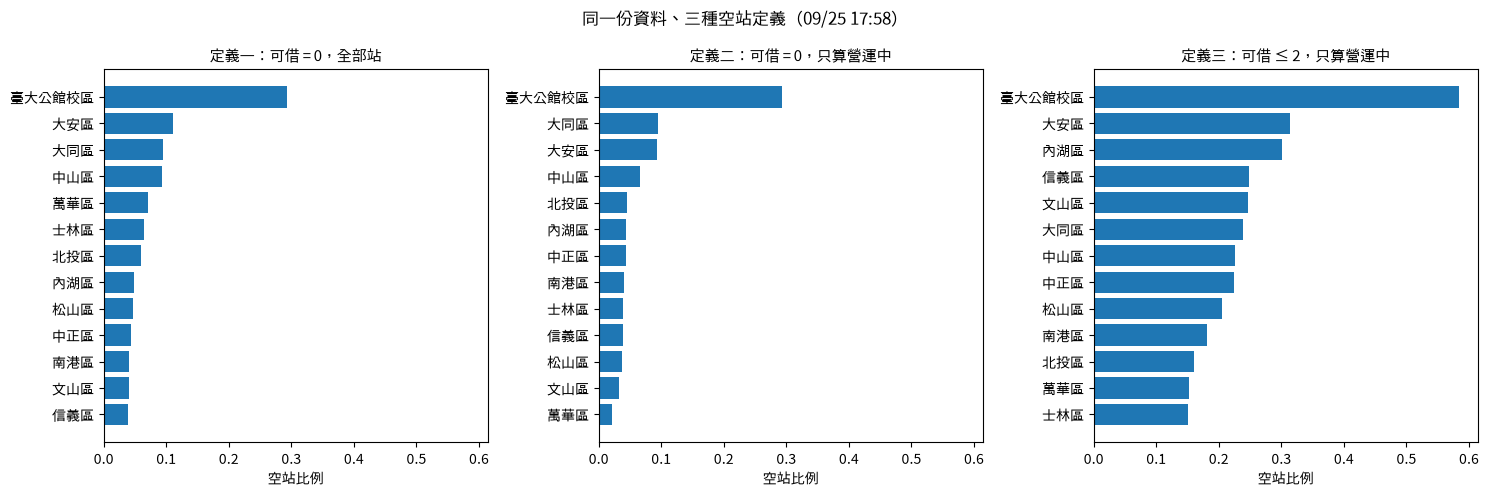

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True)

for ax, (名稱, 表) in zip(axes, 結果.items()):
    s = 表[目標時段].sort_values()
    ax.barh(s.index, s.values)
    ax.set_title(名稱, fontsize=11)
    ax.set_xlabel("空站比例")

fig.suptitle(f"同一份資料、三種空站定義（{目標時段}）")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "w3_三種空站定義.png", dpi=150)
plt.show()

## F2. 各區 × 各時段

`pivot_table` 做出來的寬表可以直接 `.plot()`：每一欄（時段）畫成一組長條。

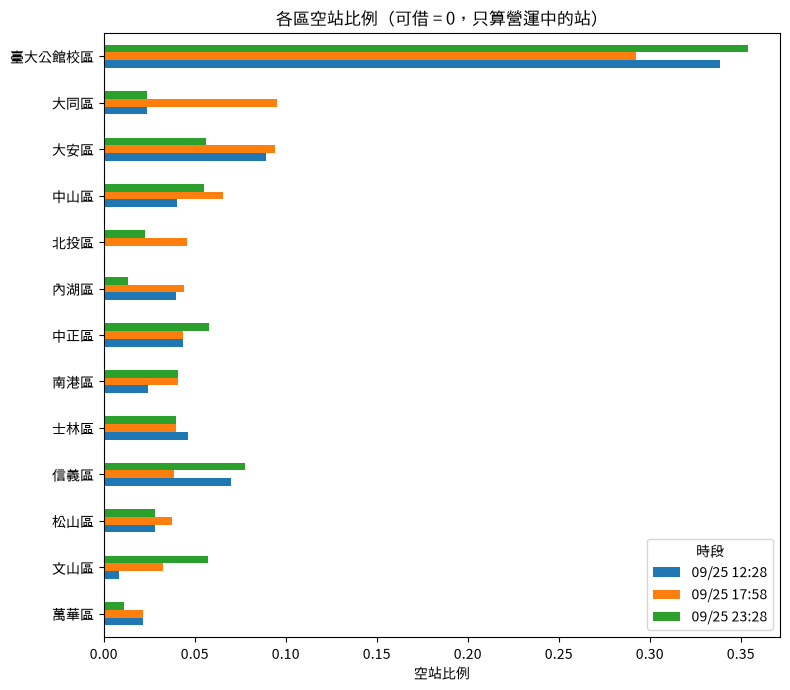

In [ ]:
表 = 結果["定義二：可借 = 0，只算營運中"]

ax = 表.sort_values(目標時段).plot.barh(figsize=(8, 7))
ax.set_title("各區空站比例（可借 = 0，只算營運中的站）")
ax.set_xlabel("空站比例")
ax.set_ylabel("")
ax.legend(title="時段")
plt.tight_layout()
plt.show()

**【練習 F】** 修改上面這張圖：

1. x 軸改成百分比顯示（提示：`from matplotlib.ticker import PercentFormatter`，`ax.xaxis.set_major_formatter(PercentFormatter(1))`）。
2. 標題下方加上資料來源：臺北市 YouBike 2.0 即時資料。
3. 存到 `OUTPUT_DIR`。

In [ ]:
# TODO：x 軸改成百分比、加上資料來源、存檔

---

## 本週回顧

| 你學到的 | 為什麼重要 |
|---|---|
| 向量化：整欄一起算 | 好讀、好檢查，也比迴圈快很多 |
| 比例＝布林值的 `.mean()` | 空站比例、滿站比例都是這樣算的 |
| `read_json` 會自動轉型 | `act == "1"` 可能一站都選不到，而且不會報錯 |
| 用迴圈＋`assert` 驗證 `groupby` | agent 的一行程式，要用你看得懂的方法對答案 |
| 長表、寬表、`merge` 的 `indicator` | 站數會變動，`inner` 會默默丟掉資料 |
| 定義、分母、代表值 | 換一個定義，排名和結論就可能改變 |
| 多張圖用同一個座標範圍 | 不同的尺度會誤導讀者 |

**HW3（10/07 截止）：** 用你自己在 HW2 起存的至少 3 個時段快照，完成「行政區 × 時段」的空站與滿站分析。詳見 `HW3_作業說明`。

**記得：** 打開 AI 之前，先寫筆記的 Before AI 欄位。